Step 1: Landscape engineering (preprocess)

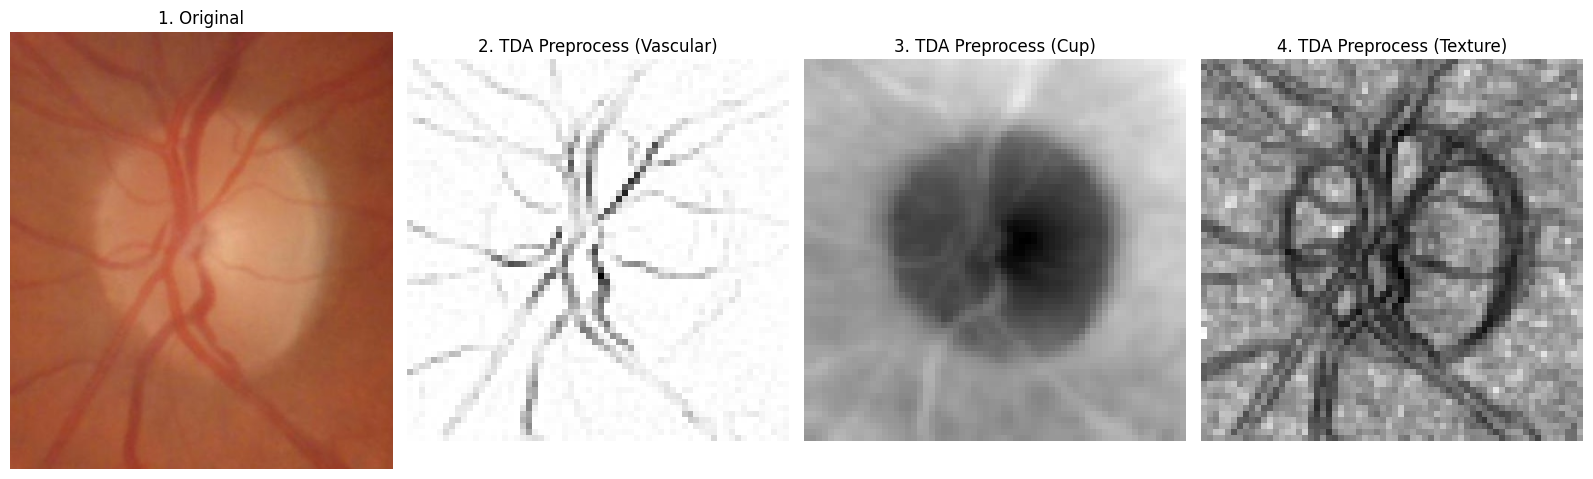

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.filters.rank import entropy
from skimage.morphology import disk


def preprocess_for_tda_vascular_test(img_bgr):
    """Produce normalized vessel image (Green channel)"""
    # Split RGB Channels
    _, green, _ = cv2.split(img_bgr)
    
    # blur slightly to remove noise, then run Frangi
    g_blur = cv2.GaussianBlur(green, (5, 5), 0)
    frangi_map = frangi(g_blur, sigmas=range(2, 6, 1), black_ridges=True)
    
    # normalize output to 0.0 - 1.0
    vascular_landscape = cv2.normalize(frangi_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    # resize
    small_vascular = cv2.resize(vascular_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    
    # invert
    vascular_norm = 1.0 - (small_vascular / 255.0)
    
    return vascular_norm

def preprocess_for_tda_cup_test(img_bgr):
    """Produce normalized cup image (Red channel)"""
    # Split RGB Channels
    _, _, red = cv2.split(img_bgr)
    
    # blur heavily to remove vessel shadows, leaving the geometry of optic disc
    r_blur = cv2.GaussianBlur(red, (21, 21), 0)
    
    # normalize output to 0.0 - 1.0
    cup_landscape = cv2.normalize(r_blur, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    # resize
    small_cup = cv2.resize(cup_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    
    # invert
    cup_norm =  1.0 - (small_cup / 255.0)
    
    return cup_norm

def preprocess_for_tda_texture_test(img_bgr):
    """Produce normalized texture image (Grayscale)"""
    # Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Calculate Local Entropy (Texture)
    # A disk of 5 pixels sweeps the image. 
    # Smooth areas get a low score (0). Rough/patchy areas get a high score.
    texture_map = entropy(gray, disk(5))
    
    # normalize output to 0.0 - 1.0
    texture_landscape = cv2.normalize(texture_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    
    # resize
    small_texture = cv2.resize(texture_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    
    # invert
    texture_norm = 1.0 - (small_texture/ 255.0)
    
    return texture_norm

TEST_IMAGE_PATH = "image_cropped/train/GON+/82_0.jpg"
img_raw = cv2.imread(TEST_IMAGE_PATH)
img_rgb_original = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

# Run the three pipelines
tda_preprocessed_vascular = preprocess_for_tda_vascular_test(img_raw)
tda_preprocessed_cup = preprocess_for_tda_cup_test(img_raw)
tda_preprocessed_texture = preprocess_for_tda_texture_test(img_raw)

# Visualize
plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(img_rgb_original)
plt.title("1. Original")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(tda_preprocessed_vascular, cmap='gray')
plt.title("2. TDA Preprocess (Vascular)")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(tda_preprocessed_cup, cmap='gray')
plt.title("3. TDA Preprocess (Cup)")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(tda_preprocessed_texture, cmap='gray')
plt.title("4. TDA Preprocess (Texture)")
plt.axis('off')

plt.tight_layout()
plt.show()

Image preprocessing applied to all images (manually choose directory)

In [ ]:
from pathlib import Path
from tqdm import tqdm

def preprocess_for_tda_vascular(img_bgr):
    """Produce normalized vessel image (Green channel)"""
    # Split RGB Channels
    _, green, _ = cv2.split(img_bgr)
    
    # blur slightly to remove noise, then run Frangi
    g_blur = cv2.GaussianBlur(green, (5, 5), 0)
    frangi_map = frangi(g_blur, sigmas=range(2, 6, 1), black_ridges=True)
    
    # normalize output to 0.0 - 1.0
    vascular_landscape = cv2.normalize(frangi_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    # resize
    small_vascular = cv2.resize(vascular_landscape, (64, 64), interpolation=cv2.INTER_AREA)

    # invert
    vascular_norm = 1.0 - small_vascular
    
    return (vascular_norm * 255).astype(np.uint8)

def preprocess_for_tda_cup(img_bgr):
    """Produce normalized cup image (Red channel)"""
    # Split RGB Channels
    _, _, red = cv2.split(img_bgr)
    
    # blur heavily to remove vessel shadows, leaving the geometry of optic disc
    r_blur = cv2.GaussianBlur(red, (21, 21), 0)
    
    # normalize output to 0.0 - 1.0
    cup_landscape = cv2.normalize(r_blur, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    # resize
    small_cup = cv2.resize(cup_landscape, (64, 64), interpolation=cv2.INTER_AREA)

    # invert
    cup_norm =  1.0 - small_cup
    
    return (cup_norm * 255).astype(np.uint8)

def preprocess_for_tda_texture(img_bgr):
    """Produce normalized texture image (Grayscale)"""
    # Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Calculate Local Entropy (Texture)
    # A disk of 5 pixels sweeps the image. 
    # Smooth areas get a low score (0). Rough/patchy areas get a high score.
    texture_map = entropy(gray, disk(5))
    
    # normalize output to 0.0 - 1.0
    texture_landscape = cv2.normalize(texture_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    
    # resize
    small_texture = cv2.resize(texture_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    
    # invert
    texture_norm = 1.0 - small_texture
    
    return (texture_norm * 255).astype(np.uint8)

INPUT_DIR = Path("image_cropped/test/GON-")  # <--- Modify for all subfolder
OUTPUT_DIR = Path("image_cropped_tda/test/GON-") # <--- Modify for all subfolder
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

extensions = ['*.jpg']
image_files = []
for ext in extensions:
    image_files.extend(INPUT_DIR.glob(ext))
    
print(f"Found {len(image_files)} images in {INPUT_DIR}")
print(f"Processing and saving to {OUTPUT_DIR}...")
    
for img_path in tqdm(image_files):
    img = cv2.imread(str(img_path))
    vessel_img, cup_img, texture_img = preprocess_for_tda_vascular(img), preprocess_for_tda_cup(img), preprocess_for_tda_texture(img)
    base_name = img_path.stem
            
    cv2.imwrite(str(OUTPUT_DIR / f"{base_name}_vessel.png"), vessel_img)
    cv2.imwrite(str(OUTPUT_DIR / f"{base_name}_cup.png"), cup_img)
    cv2.imwrite(str(OUTPUT_DIR / f"{base_name}_texture.png"), texture_img)
    

print("✅ Done! Images are processed.")


Found 33 images in image_cropped\test\GON-
Processing and saving to image_cropped_tda\test\GON-...


100%|██████████| 33/33 [00:13<00:00,  2.45it/s]

✅ Done! Images are processed.


Apply Cubical Homology and save to csv

In [3]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm


from gtda.homology import CubicalPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy, BettiCurve, PersistenceImage

def extract_features_from_landscape(path, cubical_engine, feature_extractor, prefix):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    diagrams = cubical_engine.fit_transform(img[None, :, :])

    features ={}
    for name, extractor in feature_extractor.items():
        # values shape depends on the extractor!
        values = extractor.fit_transform(diagrams)[0] 
        
        # Scenario A: Amplitude or Entropy (Returns 2 flat numbers)
        if values.ndim == 1 and len(values) == 2:
            features[f'{prefix}_{name}_H0'] = values[0]
            features[f'{prefix}_{name}_H1'] = values[1]
            
        # Scenario B: Betti Curve (Returns two arrays of length n_bins)
        elif values.ndim == 2 and len(values) == 2:
            for bin_idx in range(values.shape[1]):
                features[f'{prefix}_{name}_H0_bin{bin_idx}'] = values[0][bin_idx]
                features[f'{prefix}_{name}_H1_bin{bin_idx}'] = values[1][bin_idx]  

        # Scenario C: Persistence Image
        # Returns 3D array:[2, n_bins_x, n_bins_y]
        elif values.ndim == 3 and len(values) == 2:
            h0_flat = values[0].flatten()
            h1_flat = values[1].flatten()
            # If n_bins=5, len(h0_flat) will be 25
            for px_idx in range(len(h0_flat)):
                features[f'{prefix}_{name}_H0_px{px_idx}'] = h0_flat[px_idx]
                features[f'{prefix}_{name}_H1_px{px_idx}'] = h1_flat[px_idx]

    return features

INPUT_DIR = Path("image_split_tda/test/GON-")  
OUTPUT_CSV = "tda_test_negative.csv"

cubical = CubicalPersistence(homology_dimensions=[0, 1])
metrics =['bottleneck', 'wasserstein', 'betti', 'landscape', 'heat']

extractors = {}

for m in ['bottleneck', 'wasserstein', 'betti', 'landscape', 'heat']:
    extractors[f'amp_{m}'] = Amplitude(metric=m)

extractors['entropy'] = PersistenceEntropy()
extractors['betti_curve'] = BettiCurve(n_bins=10)
extractors['pi'] = PersistenceImage(sigma=0.1, n_bins=5)

all_files = list(INPUT_DIR.glob("*_vessel.png"))
base_names = [f.name.replace('_vessel.png', '') for f in all_files]

print(f"Found {len(base_names)} patient images. Starting topological feature extraction...")

dataset_records =[]

for base_name in tqdm(base_names):
    vessel_path = INPUT_DIR / f"{base_name}_vessel.png"
    cup_path = INPUT_DIR / f"{base_name}_cup.png"
    texture_path = INPUT_DIR / f"{base_name}_texture.png"

    vessel_feats = extract_features_from_landscape(vessel_path, cubical, extractors, prefix="vessel")
    cup_feats = extract_features_from_landscape(cup_path, cubical, extractors, prefix="cup")
    texture_feats = extract_features_from_landscape(texture_path, cubical, extractors, prefix="texture")

    row = {'Image Name': f"{base_name}.jpg"}

    row.update(vessel_feats)
    row.update(cup_feats)
    row.update(texture_feats)

    dataset_records.append(row)

to_save = pd.DataFrame(dataset_records)
to_save.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ TDA Extraction Complete! Saved {len(to_save)} rows to {OUTPUT_CSV}")

Found 33 patient images. Starting topological feature extraction...


100%|██████████| 33/33 [00:02<00:00, 11.04it/s]



✅ TDA Extraction Complete! Saved 33 rows to tda_test_negative.csv


Concat "Quality Score" to TDA features

In [ ]:
import pandas as pd

df_tda = pd.read_csv("tda_train_combined.csv") # <---positive and negative csv were merged manually
df_labels = pd.read_csv("train_split_dataset.csv") # <----- csv generate from train test split from CNN training

df_combined = pd.merge(df_tda, df_labels[['Image Name', 'Quality Score']], on="Image Name", how="inner")

# 3. VERIFY
print(f"Original TDA rows: {len(df_tda)}")
print(f"Merged rows: {len(df_combined)}")

# 4. SAVE
df_combined.to_csv("tda_train_final.csv", index=False)
print("✅ Successfully merged Quality Score into your TDA dataset!")

Load the finalised csv containing TDA features and Quality Score

In [4]:
import pandas as pd

df_train = pd.read_csv("tda_train_final.csv")
df_test = pd.read_csv("tda_test_final.csv")

Split into X and y, feature ablation can be conducted here by dropping features starting with certain names.

In [5]:
cols_to_drop = ['Image Name', 'label_encoded'] #+ [col for col in df_train.columns if col.startswith('cup_')] #+ [col for col in df_train.columns if col.startswith('cup_')]
X_train = df_train.drop(columns=cols_to_drop)
X_test = df_test.drop(columns=cols_to_drop)

y_train = df_train['label_encoded']
y_test = df_test['label_encoded']

Train RF model and show metrics


--- Model Evaluation ---
Accuracy: 0.8485
AUROC:    0.8733
PR-AUC:  0.9448

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.78      0.55      0.64        33
    Glaucoma       0.86      0.95      0.90        99

    accuracy                           0.85       132
   macro avg       0.82      0.75      0.77       132
weighted avg       0.84      0.85      0.84       132


--- Confusion Matrix ---


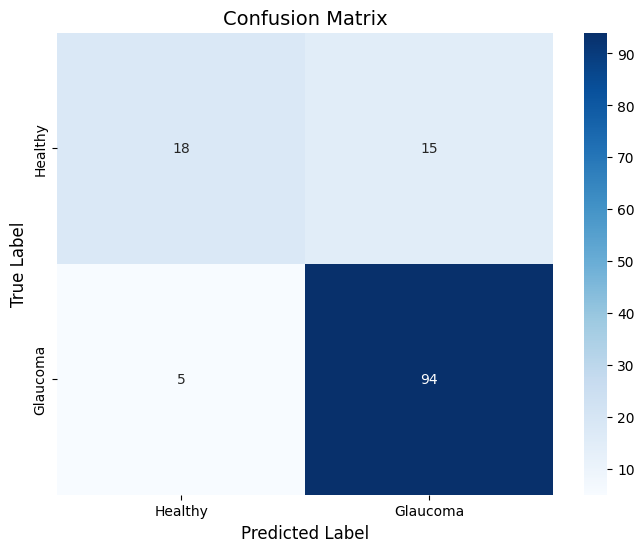

In [8]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)



print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUROC:    {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Glaucoma']))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Glaucoma'], yticklabels=['Healthy', 'Glaucoma'])
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.show()

As comparison, train XGB model and show metrics (note lower recall)

ROC-AUC: 0.8280
PR-AUC:  0.9200
Accuracy: 0.8561

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.61      0.68        33
           1       0.88      0.94      0.91        99

    accuracy                           0.86       132
   macro avg       0.82      0.77      0.79       132
weighted avg       0.85      0.86      0.85       132


--- Confusion Matrix ---


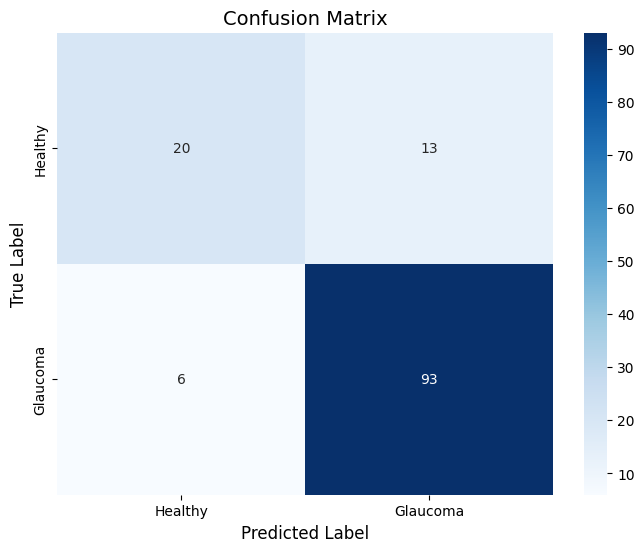

In [10]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=1000,           
    learning_rate=0.01,          
    max_depth=5,                 
    min_child_weight=5,         
    subsample=0.8,               
    colsample_bytree=0.8,
    gamma=1.0,    
    objective="binary:logistic",
    eval_metric="auc",
    
    random_state=42,
    tree_method="hist"          
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Probabilities (important!)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Binary predictions (default threshold = 0.5)
y_pred = (y_prob >= 0.5).astype(int)

# AUROC
roc_auc = roc_auc_score(y_test, y_prob)

# PR-AUC (more informative for imbalance)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Glaucoma'], yticklabels=['Healthy', 'Glaucoma'])
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.show()

Script to locate decision boundary

In [13]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest Threshold (F1): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall:    {recall[best_idx]:.4f}")
print(f"F1 Score:  {f1_scores[best_idx]:.4f}")


Best Threshold (F1): 0.3515
Precision: 0.8661
Recall:    0.9798
F1 Score:  0.9194


Gini importance visualised using built-in feature importance method

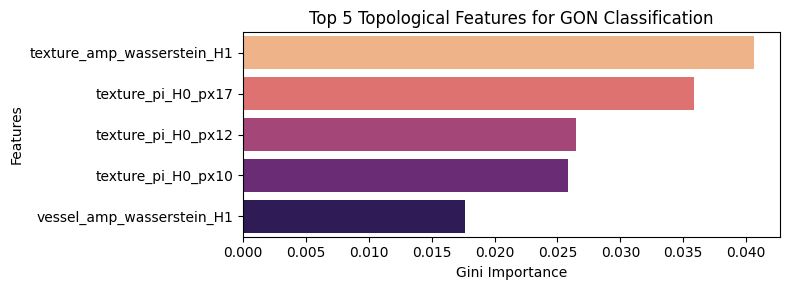

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf.feature_importances_
feature_names = X_train.columns

forest_importances = pd.Series(importances, index=feature_names)
forest_importances = forest_importances.sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 3))
sns.barplot(x=forest_importances.values, y=forest_importances.index, hue=forest_importances.index, palette="magma_r", legend=False)
plt.title("Top 5 Topological Features for GON Classification")
plt.xlabel("Gini Importance")
plt.ylabel("Features")
plt.tight_layout()

SHAP for local interpretability

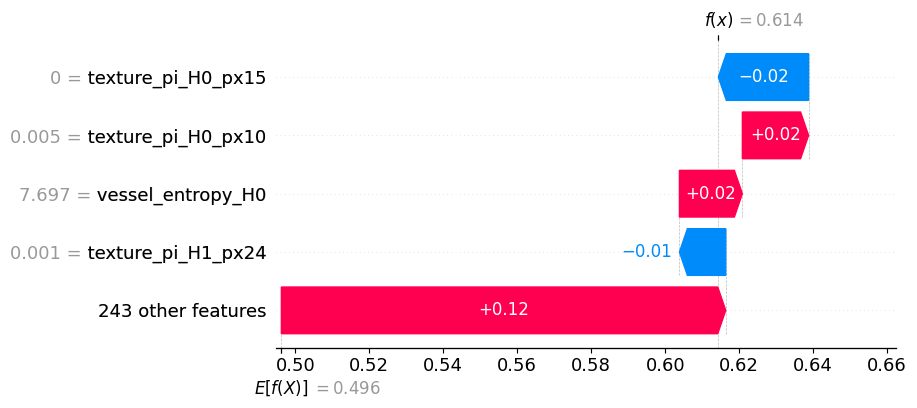

In [12]:
import shap
import numpy as np

# 1. Get Patient Data
patient_data = df_test.drop(columns=['Image Name', 'label_encoded']).iloc[[5]]

# 2. Get SHAP Values for the Positive Class
explainer = shap.TreeExplainer(rf)
shap_values_obj = explainer(patient_data)[:, :, 1]

# 3. Create explanation directly from original features (NO binning)
bv = shap_values_obj.base_values[0]

final_explanation = shap.Explanation(
    values=shap_values_obj.values[0],  # All original feature SHAP values
    base_values=bv,
    data=patient_data.values[0],  # Original feature values
    feature_names=patient_data.columns.tolist()
)

# 4. Plot - but filter to only show meaningful contributions
shap.plots.waterfall(final_explanation, max_display=5)  # Show top 30 features


Bin features according to landscape for SHAP

In [11]:
prefix_map = {
    'cup_': 'Optic Disc Features',
    'vessel_': 'Vascular Features',
    'texture_': 'Peripapillary Features',
    'Quality': 'Image Quality Score'
}

category_map = {label: [] for label in prefix_map.values()}
category_map['Other'] = [] 

for col in X_train.columns:
    found = False
    for prefix, label in prefix_map.items():
        if col.startswith(prefix):
            category_map[label].append(col)
            found = True
            break
    if not found:
        category_map['Other'].append(col)


SHAP with features binned

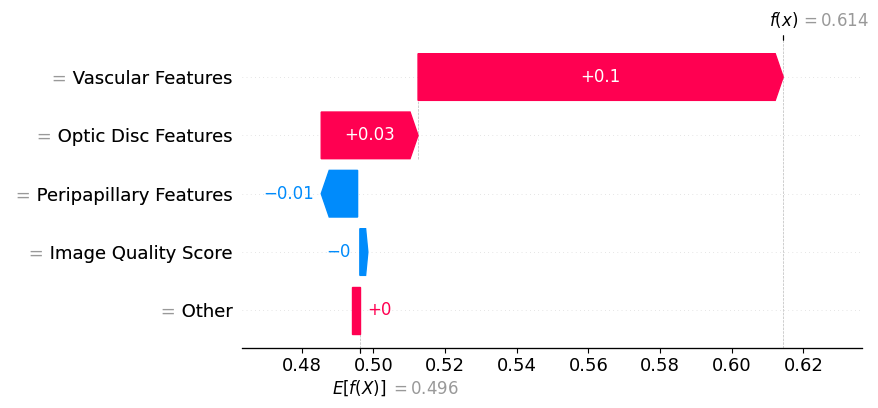

In [60]:
import shap
import numpy as np

# 1. Get Patient Data
patient_data = df_test.drop(columns=['Image Name', 'label_encoded']).iloc[[5]]

# 2. Get SHAP Values ONLY for the Positive Class (Index 1)
explainer = shap.TreeExplainer(rf)
# The slicing means: [all_patients, all_features, class_1]
shap_values_obj = explainer(patient_data)[:, :, 1] 

# 3. Aggregate the values
group_names = list(category_map.keys())
aggregated_values = []

for cat in group_names:
    indices = [patient_data.columns.get_loc(f) for f in category_map[cat] if f in patient_data.columns]
    
    # Safety check: If a category is empty, sum is 0
    if len(indices) > 0:
        cat_sum = shap_values_obj.values[:, indices].sum(axis=1)
    else:
        cat_sum = np.array([0.0])
        
    aggregated_values.append(cat_sum)

# Convert list of arrays into a single flat 1D array
val_1d = np.array(aggregated_values).flatten()

# 4. Extract exactly ONE number for the base value
bv = shap_values_obj.base_values[0] 

# 5. Create dummy data to match the length of categories
data_1d = np.full(len(val_1d), "")

# 6. Build the explicitly 1D Explanation
final_explanation = shap.Explanation(
    values=val_1d,
    base_values=bv,
    data=data_1d, 
    feature_names=group_names
)

# 7. Plot
shap.plots.waterfall(final_explanation)

Export RF model for streamlit app

In [14]:
import joblib
joblib.dump(rf, 'tda_rf_model.joblib')

['tda_rf_model.joblib']